In [63]:
import sys
sys.path.append('../../')
from ctw.ctw import CTW
from mingpt.model import GPT
from mingpt.trainer import Trainer
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Attention head analysis

In this notebook we attempt to observe counting in the attention heads of a transformer used to make bit predictions. We compare to bit predictions that are based on multiple priors Beta(1, 1), Beta(5, 2), Beta(2, 5)

$$\hat{p} = \frac{k + 1}{n + 2}$$

In [64]:
import sys
sys.path.append('../../')

from mingpt.model import GPT
import torch
import os

MODEL_DIR = './models/'

model_registry = {
    'beta_0p5_0p5_model.pt': (0.5, 0.5),
    'beta_1p0_1p0_model.pt': (1.0, 1.0),
    'beta_2p0_5p0_model.pt': (2.0, 5.0),
    'beta_5p0_2p0_model.pt': (5.0, 2.0),
    'beta_5p0_5p0_model.pt': (5.0, 5.0),
}

def load_model(filename):
    path = os.path.join(MODEL_DIR, filename)
    checkpoint = torch.load(path, map_location='mps', weights_only=False)
    config = GPT.get_default_config()
    config.model_type = 'gpt-nano'
    config.vocab_size = 2
    config.block_size = checkpoint['block_size']
    model = GPT(config)
    model.load_state_dict(checkpoint['state_dict'])
    return model.to('mps').eval()

models = {
    filename: {
        'model': load_model(filename),
        'alpha': alpha,
        'beta':  beta,
        'label': f'Beta({alpha},{beta})',
    }
    for filename, (alpha, beta) in model_registry.items()
}

print("Loaded models:")
for fname, m in models.items():
    print(f"  {m['label']:15s}  block_size={m['model'].block_size}")

number of parameters: 0.11M
number of parameters: 0.11M
number of parameters: 0.11M
number of parameters: 0.11M
number of parameters: 0.11M
Loaded models:
  Beta(0.5,0.5)    block_size=499
  Beta(1.0,1.0)    block_size=499
  Beta(2.0,5.0)    block_size=499
  Beta(5.0,2.0)    block_size=499
  Beta(5.0,5.0)    block_size=499


In [65]:
import numpy as np

N_SEQS = 50
SEQ_LEN = 499
P_TEST = 0.5  # neutral, no prior assumption

rng = np.random.default_rng(seed=42)
test_sequences = rng.binomial(1, P_TEST, size=(N_SEQS, SEQ_LEN))  # [50, 500]

def compute_kt_over_t(sequence):
    """
    k_t/t at each position t: empirical frequency of 1s seen before position t.
    position 0 has no context, pad with 0.5.
    """
    targets = np.zeros(len(sequence))
    targets[0] = 0.5
    k = 0
    for t in range(1, len(sequence)):
        k += sequence[t - 1]
        targets[t] = k / t
    return targets

# precompute targets for all sequences
targets = np.array([compute_kt_over_t(seq) for seq in test_sequences])  # [50, 500]

print(f"test_sequences: {test_sequences.shape}")
print(f"targets:        {targets.shape}")
print(f"targets[0, :5]: {targets[0, :5]}")  # sanity check first few values


    
        


test_sequences: (50, 499)
targets:        (50, 499)
targets[0, :5]: [0.5        1.         0.5        0.66666667 0.75      ]


# Linear probes

At the output of the attention head, we fit a vector w such that

$$w \cdot x[t] + b \approx \frac{k_t}{t} $$

In the following cell, we extract attention outputs

In [66]:
def extract_attn_outputs(sequence, model):
    """
    Returns attention outputs per layer per head.
    Shape: [n_layers, n_heads, T, head_size] = [3, 3, 500, 16]
    """
    x = torch.tensor(sequence, dtype=torch.long, device='mps').unsqueeze(0)
    with torch.no_grad():
        model(x)
    
    outputs = []
    for layer_idx in range(3):
        cached = model.transformer.h[layer_idx].attn._attn_output  # [1, 3, 500, 16]
        outputs.append(cached.squeeze(0).cpu().numpy())             # [3, 500, 16]
    
    return np.array(outputs)  # [3, 3, 500, 16]

# collect across all sequences for each model
# results[filename] = [50, 3, 3, 500, 16]
all_outputs = {}
for filename, m in models.items():
    model_outputs = []
    for seq in test_sequences:
        model_outputs.append(extract_attn_outputs(seq, m['model']))
    all_outputs[filename] = np.array(model_outputs)
    print(f"  {m['label']}  →  {all_outputs[filename].shape}")

  Beta(0.5,0.5)  →  (50, 3, 3, 499, 16)
  Beta(1.0,1.0)  →  (50, 3, 3, 499, 16)
  Beta(2.0,5.0)  →  (50, 3, 3, 499, 16)
  Beta(5.0,2.0)  →  (50, 3, 3, 499, 16)
  Beta(5.0,5.0)  →  (50, 3, 3, 499, 16)


In [67]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# targets flattened: [50*500] = [25000]
targets_flat = targets.flatten()

probe_results = {}

for filename, m in models.items():
    data = all_outputs[filename]  # [50, 3, 3, 500, 16]
    r2_grid = np.zeros((3, 3))    # [n_layers, n_heads]
    
    for layer in range(3):
        for head in range(3):
            # X: [50*500, 16]
            X = data[:, layer, head, :, :].reshape(-1, 16)
            
            probe = Ridge(alpha=1e-3).fit(X, targets_flat)
            r2_grid[layer, head] = r2_score(targets_flat, probe.predict(X))
    
    probe_results[filename] = r2_grid
    print(f"\n{m['label']}")
    print(f"  R² per [layer, head]:\n{np.round(r2_grid, 4)}")


Beta(0.5,0.5)
  R² per [layer, head]:
[[0.2246 0.5495 0.4457]
 [0.1103 0.1131 0.0986]
 [0.2048 0.3263 0.1075]]

Beta(1.0,1.0)
  R² per [layer, head]:
[[0.3835 0.6122 0.5777]
 [0.1103 0.2348 0.2657]
 [0.1369 0.2231 0.2518]]

Beta(2.0,5.0)
  R² per [layer, head]:
[[0.5677 0.7038 0.6966]
 [0.3868 0.4812 0.2836]
 [0.2958 0.4054 0.3146]]

Beta(5.0,2.0)
  R² per [layer, head]:
[[0.6905 0.6568 0.7459]
 [0.4136 0.5666 0.3681]
 [0.2235 0.3394 0.3444]]

Beta(5.0,5.0)
  R² per [layer, head]:
[[0.6146 0.7559 0.6066]
 [0.6995 0.599  0.7275]
 [0.5137 0.7316 0.6056]]


In [68]:
import pandas as pd

for filename, m in models.items():
    grid = probe_results[filename]
    df = pd.DataFrame(
        grid,
        index=[f'Layer {i}' for i in range(3)],
        columns=[f'Head {j}' for j in range(3)]
    )
    print(f"\n{m['label']}")
    print(df.round(4).to_string())


Beta(0.5,0.5)
         Head 0  Head 1  Head 2
Layer 0  0.2246  0.5495  0.4457
Layer 1  0.1103  0.1131  0.0986
Layer 2  0.2048  0.3263  0.1075

Beta(1.0,1.0)
         Head 0  Head 1  Head 2
Layer 0  0.3835  0.6122  0.5777
Layer 1  0.1103  0.2348  0.2657
Layer 2  0.1369  0.2231  0.2518

Beta(2.0,5.0)
         Head 0  Head 1  Head 2
Layer 0  0.5677  0.7038  0.6966
Layer 1  0.3868  0.4812  0.2836
Layer 2  0.2958  0.4054  0.3146

Beta(5.0,2.0)
         Head 0  Head 1  Head 2
Layer 0  0.6905  0.6568  0.7459
Layer 1  0.4136  0.5666  0.3681
Layer 2  0.2235  0.3394  0.3444

Beta(5.0,5.0)
         Head 0  Head 1  Head 2
Layer 0  0.6146  0.7559  0.6066
Layer 1  0.6995  0.5990  0.7275
Layer 2  0.5137  0.7316  0.6056


In [69]:
def compute_bayes_target(sequence, alpha, beta):
    targets = np.zeros(len(sequence))
    targets[0] = alpha / (alpha + beta)  # prior mean, no data yet
    k = 0
    for t in range(1, len(sequence)):
        k += sequence[t - 1]
        targets[t] = (k + alpha) / (t + alpha + beta)
    return targets

bayes_probe_results = {}

for filename, m in models.items():
    alpha, beta = m['alpha'], m['beta']
    
    bayes_targets = np.array([compute_bayes_target(seq, alpha, beta)
                               for seq in test_sequences])
    bayes_targets_flat = bayes_targets.flatten()
    
    data = all_outputs[filename]
    r2_grid = np.zeros((3, 3))
    
    for layer in range(3):
        for head in range(3):
            X = data[:, layer, head, :, :].reshape(-1, 16)
            probe = Ridge(alpha=1e-3).fit(X, bayes_targets_flat)
            r2_grid[layer, head] = r2_score(bayes_targets_flat, probe.predict(X))
    
    bayes_probe_results[filename] = r2_grid

for filename, m in models.items():
    grid = bayes_probe_results[filename]
    df = pd.DataFrame(
        grid,
        index=[f'Layer {i}' for i in range(3)],
        columns=[f'Head {j}' for j in range(3)]
    )
    print(f"\n{m['label']}")
    print(df.round(4).to_string())


Beta(0.5,0.5)
         Head 0  Head 1  Head 2
Layer 0  0.2339  0.5808  0.4728
Layer 1  0.0913  0.0821  0.0729
Layer 2  0.1992  0.3313  0.0955

Beta(1.0,1.0)
         Head 0  Head 1  Head 2
Layer 0  0.4140  0.6660  0.6269
Layer 1  0.0710  0.2239  0.2058
Layer 2  0.1007  0.2095  0.2215

Beta(2.0,5.0)
         Head 0  Head 1  Head 2
Layer 0  0.6610  0.7821  0.7844
Layer 1  0.4933  0.6109  0.3671
Layer 2  0.4149  0.4795  0.4257

Beta(5.0,2.0)
         Head 0  Head 1  Head 2
Layer 0  0.8107  0.7808  0.8532
Layer 1  0.5796  0.7249  0.5329
Layer 2  0.4076  0.4886  0.5094

Beta(5.0,5.0)
         Head 0  Head 1  Head 2
Layer 0  0.6335  0.7802  0.6339
Layer 1  0.7811  0.6677  0.8239
Layer 2  0.4775  0.8310  0.6658


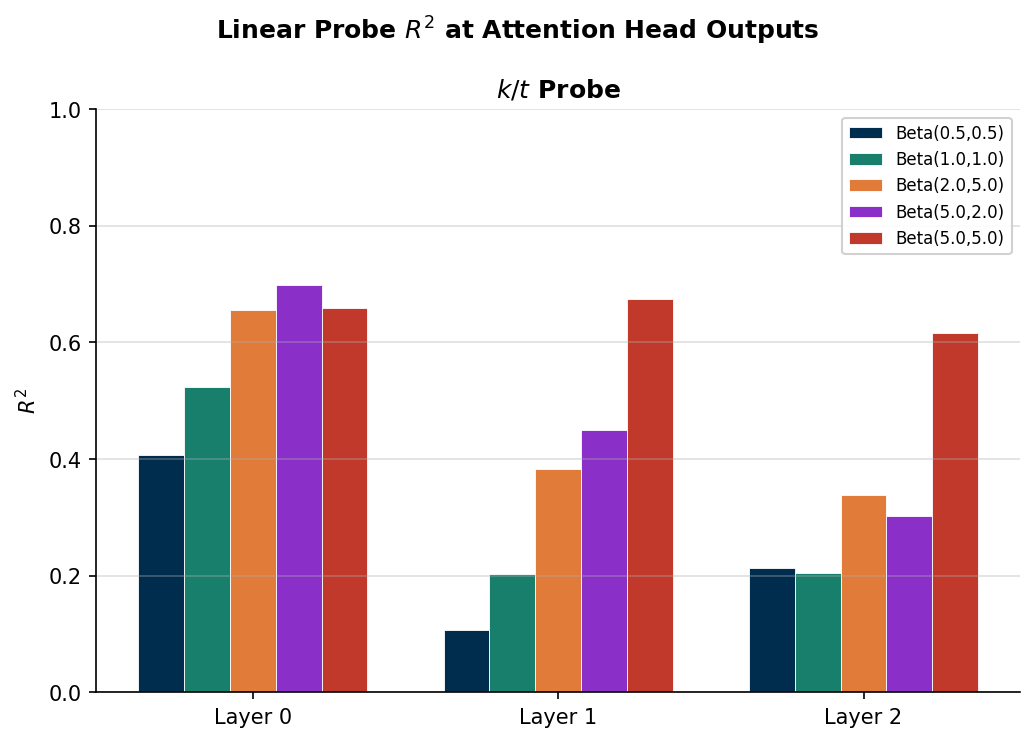

Saved figures/attention_r2


In [70]:
BG        = '#FFFFFF'
filenames  = list(models.keys())
labels     = [models[f]['label'] for f in filenames]
n_models   = len(filenames)
n_layers   = 3
bar_width  = 0.15
x          = np.arange(n_layers)

colors = [
    '#002d4d',
    '#177F6B',
    '#E07B39',
    '#8B2FC9',
    '#C0392B',
]

# --- Plot 1: k/t probe ---
fig1, ax1 = plt.subplots(figsize=(7, 5), dpi=150)
fig1.patch.set_facecolor(BG)

for i, filename in enumerate(filenames):
    grid   = probe_results[filename]
    means  = grid.mean(axis=1)
    offset = (i - n_models / 2 + 0.5) * bar_width
    ax1.bar(x + offset, means, width=bar_width,
            color=colors[i], label=labels[i],
            edgecolor='white', linewidth=0.4)

ax1.set_xticks(x)
ax1.set_xticklabels([f'Layer {l}' for l in range(n_layers)])
ax1.set_ylabel('$R^2$')
ax1.set_ylim(0, 1)
ax1.set_title(r'$k/t$ Probe', fontweight='bold')
ax1.legend(fontsize=8, framealpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, axis='y', alpha=0.4)

fig1.suptitle('Linear Probe $R^2$ at Attention Head Outputs',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/attention_r2.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/attention_r2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/attention_r2')


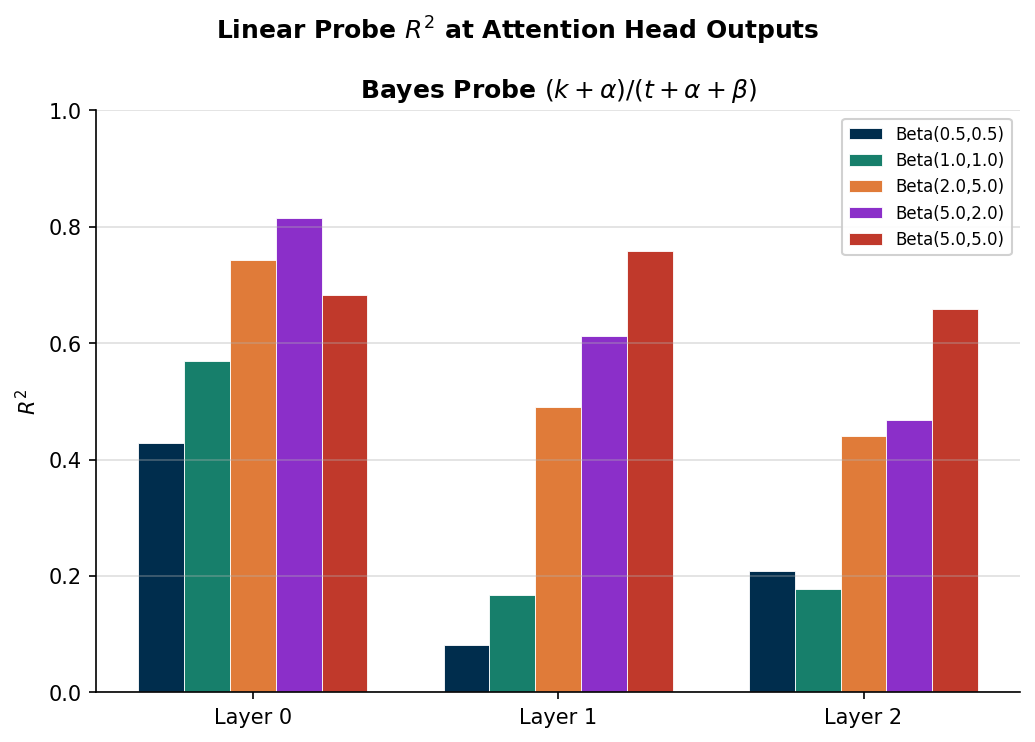

Saved figures/attention_r2_bayes


In [71]:
# --- Plot 2: Bayes probe ---
fig2, ax2 = plt.subplots(figsize=(7, 5), dpi=150)
fig2.patch.set_facecolor(BG)

for i, filename in enumerate(filenames):
    grid   = bayes_probe_results[filename]
    means  = grid.mean(axis=1)
    offset = (i - n_models / 2 + 0.5) * bar_width
    ax2.bar(x + offset, means, width=bar_width,
            color=colors[i], label=labels[i],
            edgecolor='white', linewidth=0.4)

ax2.set_xticks(x)
ax2.set_xticklabels([f'Layer {l}' for l in range(n_layers)])
ax2.set_ylabel('$R^2$')
ax2.set_ylim(0, 1)
ax2.set_title(r'Bayes Probe $(k+\alpha)/(t+\alpha+\beta)$', fontweight='bold')
ax2.legend(fontsize=8, framealpha=0.9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, axis='y', alpha=0.4)

fig2.suptitle('Linear Probe $R^2$ at Attention Head Outputs',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/attention_r2_bayes.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/attention_r2_bayes.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/attention_r2_bayes')
